## Fetch and Display NYSE Stock Data

### yfinance module 추가
nyse 종목

In [8]:
# _tsa_00.py
# time series stuff, basic
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들.
# 자기공분산, 자기상관, 단위근
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게.

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [27]:
import pandas as pd
import yfinance as yf

# 1. 나스닥 주요 상위 종목 티커 리스트 정의
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META", "GOOGL", "TSLA", "AVGO", "COST", "NFLX"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for ticker in tickers:
    stock = yf.Ticker(ticker)
    info = stock.info

    stock_data.append({
        "티커": ticker,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
df_dat.info()   # ticker마다 close, open, volume 등

df_dat_cls = df_dat['Close'].copy()
df_dat_cls

/tmp/ipykernel_2555/1824500382.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
[**********            20%                       ]  2 of 10 completed

      티커                           기업명                      섹터  현재가($)  \
0   AAPL                    Apple Inc.              Technology  316.22   
1   MSFT         Microsoft Corporation              Technology  493.95   
2   NVDA            NVIDIA Corporation              Technology  225.73   
3   AMZN              Amazon.com, Inc.       Consumer Cyclical  256.97   
4   META          Meta Platforms, Inc.  Communication Services  613.48   
5  GOOGL                 Alphabet Inc.  Communication Services  338.36   
6   TSLA                   Tesla, Inc.       Consumer Cyclical  368.16   
7   AVGO                 Broadcom Inc.              Technology  368.56   
8   COST  Costco Wholesale Corporation      Consumer Defensive  910.18   
9   NFLX                 Netflix, Inc.  Communication Services   76.77   

             시가총액($)  
0  4,614,971,719,680  
1  3,667,848,331,264  
2  5,450,701,996,032  
3  2,771,758,874,624  
4  1,562,844,069,888  
5  4,138,120,773,632  
6  1,454,065,451,008  
7

[*********************100%***********************]  10 of 10 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-09 to 2026-09-08
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMZN)    251 non-null    float64
 2   (Close, AVGO)    251 non-null    float64
 3   (Close, COST)    251 non-null    float64
 4   (Close, GOOGL)   251 non-null    float64
 5   (Close, META)    251 non-null    float64
 6   (Close, MSFT)    251 non-null    float64
 7   (Close, NFLX)    251 non-null    float64
 8   (Close, NVDA)    251 non-null    float64
 9   (Close, TSLA)    251 non-null    float64
 10  (High, AAPL)     251 non-null    float64
 11  (High, AMZN)     251 non-null    float64
 12  (High, AVGO)     251 non-null    float64
 13  (High, COST)     251 non-null    float64
 14  (High, GOOGL)    251 non-null    float64
 15  (High, META)     251 non-null    float64
 16  (High, MSFT)     251 non-null    float64
 1

Ticker,AAPL,AMZN,AVGO,COST,GOOGL,META,MSFT,NFLX,NVDA,TSLA
Date,,,,,,,,,,
2025-09-09,233.487503,238.240005,334.221130,973.569641,239.008438,763.198608,494.342712,126.324997,170.532867,346.970001
2025-09-10,225.955322,230.330002,366.881805,950.742798,238.549622,749.523376,496.286713,124.771004,177.094131,347.790009
2025-09-11,229.183395,229.949997,357.014160,958.726196,239.746521,748.446899,496.921509,120.349998,176.944305,368.809998
2025-09-12,233.208557,228.149994,357.252350,962.285583,240.175400,753.121643,505.738953,118.844002,177.593506,395.940002
2025-09-15,235.828842,231.429993,361.441681,954.530701,250.957336,762.201843,511.154388,120.225998,177.523575,410.040009
...,...,...,...,...,...,...,...,...,...,...
2026-09-01,325.130005,254.919998,369.679993,939.960022,334.804779,578.539978,501.019989,80.809998,217.440002,356.089996
2026-09-02,324.959991,254.979996,367.239990,928.479980,336.903442,592.849976,496.820007,82.730003,224.410004,357.010010
2026-09-03,328.209991,258.899994,357.160004,925.409973,342.260010,610.679993,510.119995,82.669998,228.449997,376.369995


### subplots?

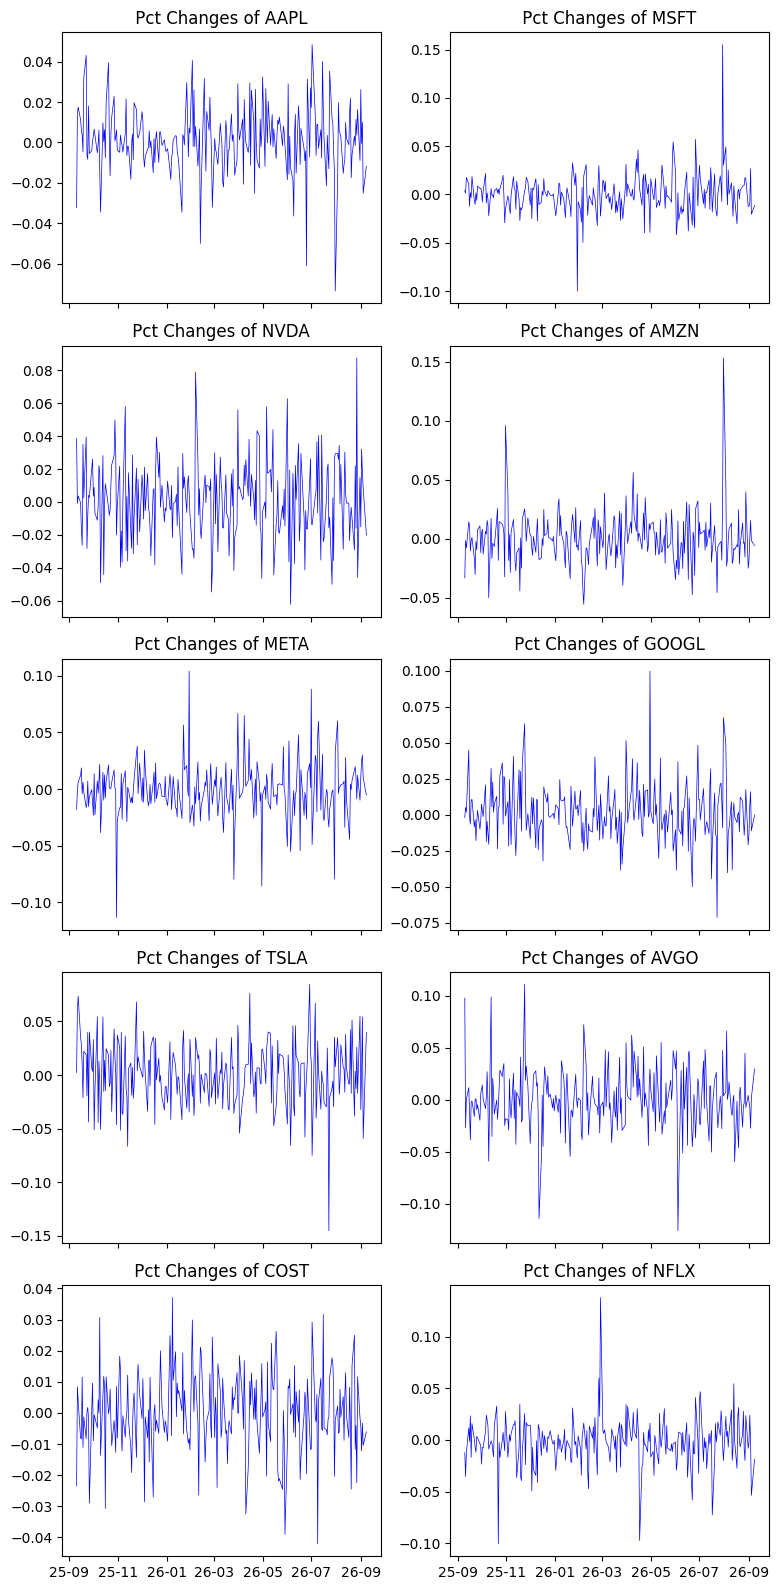

In [31]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

fig, axes = plt.subplots(5, 2, figsize=(8, 16), sharex=True)

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd, df_dat_cls[ticker].pct_change(), color='blue', linewidth=0.5)
  ax.set_title(f" Pct Changes of {ticker} ")
#  ax.set_title(f" Closing Prices of {ticker} ")
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### prices, volumes
level, differences, percentage changes

In [ ]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc = df_dat['Close']
stck_prc_dff = stck_prc.diff()
stck_prc_pct = stck_prc.pct_change()

stck_vlm = df_dat['Volume']
stck_vlm_dff = stck_vlm.diff()
stck_vlm_pct = stck_vlm.pct_change()


### time series plots
daily prices

Text(0.5, 1.0, ' Closing Prices of HYNX ')

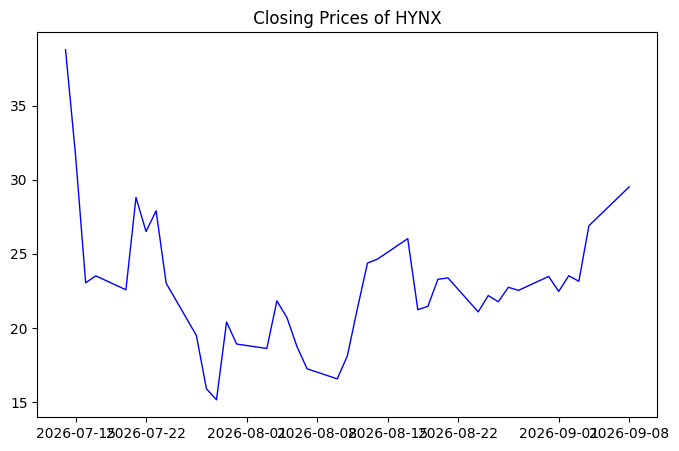

In [11]:

plt.figure(figsize=(8, 5))
#plt.subplot(figsize=(8,5  ))
plt.plot(yymmdd, stck_prc, color='blue', linewidth=1)
plt.title(f" Closing Prices of {ticker} ")


### daily changes in prices and volumes

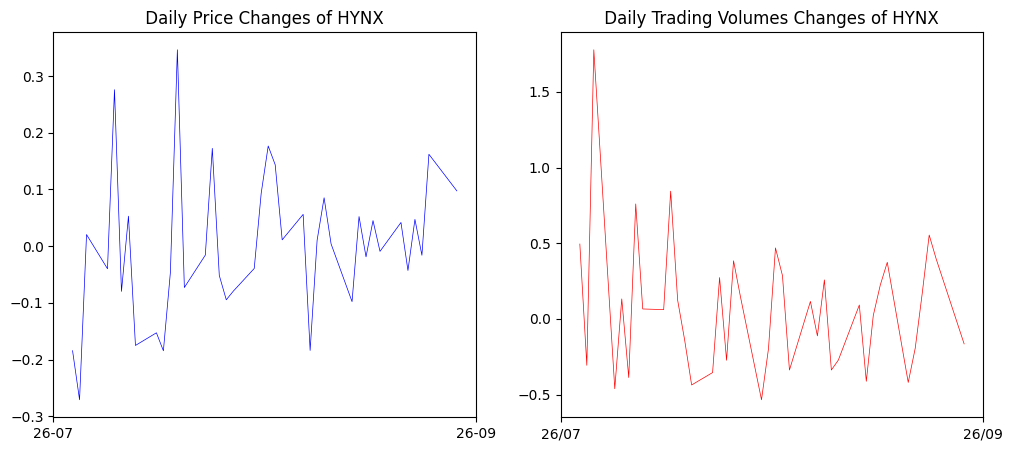

In [12]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_pct, color='blue', linewidth=0.5)
#axes[1].plot(yymmdd, stck_vlm, color='red', linewidth=0.5)
axes[1].plot(yymmdd, stck_vlm_pct, color='red', linewidth=0.5)
# axes[0].set_title(f" Closing Prices of {ticker} ")
axes[0].set_title(f" Daily Price Changes of {ticker} ")
axes[1].set_title(f" Daily Trading Volumes Changes of {ticker} ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))


### distibution of daily price changes

Text(0.5, 1.0, ' distribution of daily percentage change of HYNX ')

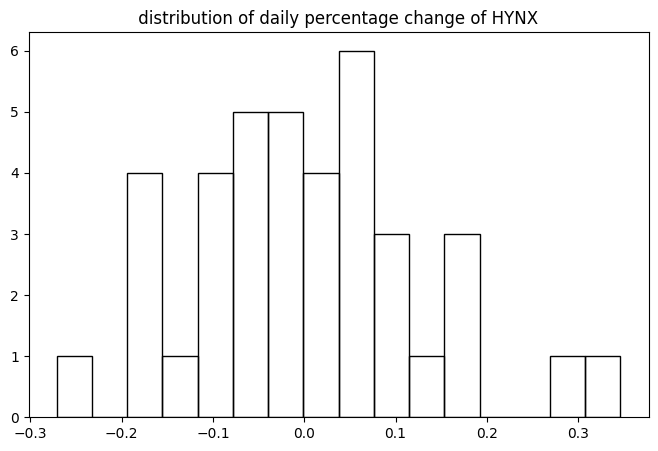

In [13]:

plt.figure(figsize=(8, 5))
plt.hist(stck_prc_pct, color='blue', linewidth=1, bins = 16, facecolor='None', edgecolor='black')
plt.title(f" distribution of daily percentage change of {ticker} ")
